In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [ ]:
np.random.seed(42)
tf.random.set_seed(42)

In [ ]:
df = pd.read_csv("Tweets.csv")

df.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


In [ ]:
print("Dataset Shape:", df.shape)

Dataset Shape: (14640, 15)


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14640 entries, 0 to 14639
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   tweet_id                      14640 non-null  int64  
 1   airline_sentiment             14640 non-null  object 
 2   airline_sentiment_confidence  14640 non-null  float64
 3   negativereason                9178 non-null   object 
 4   negativereason_confidence     10522 non-null  float64
 5   airline                       14640 non-null  object 
 6   airline_sentiment_gold        40 non-null     object 
 7   name                          14640 non-null  object 
 8   negativereason_gold           32 non-null     object 
 9   retweet_count                 14640 non-null  int64  
 10  text                          14640 non-null  object 
 11  tweet_coord                   1019 non-null   object 
 12  tweet_created                 14640 non-null  object 
 13  t

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tweet_id,14640.0,NaN,NaN,NaN,569218351767499200.0,779111158481836.75,567588278875213824.0,568559178101439488.0,569477857923110912.0,569890473289000960.0,570310600460525568.0
airline_sentiment,14640,3,negative,9178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airline_sentiment_confidence,14640.0,NaN,NaN,NaN,0.900169,0.16283,0.335,0.6923,1.0,1.0,1.0
negativereason,9178,10,Customer Service Issue,2910,NaN,NaN,NaN,NaN,NaN,NaN,NaN
negativereason_confidence,10522.0,NaN,NaN,NaN,0.638298,0.33044,0.0,0.3606,0.6706,1.0,1.0
airline,14640,6,United,3822,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airline_sentiment_gold,40,3,negative,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN
name,14640,7701,JetBlueNews,63,NaN,NaN,NaN,NaN,NaN,NaN,NaN
negativereason_gold,32,13,Customer Service Issue,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
retweet_count,14640.0,NaN,NaN,NaN,0.08265,0.745778,0.0,0.0,0.0,0.0,44.0


In [ ]:
print("Columns:")
print(df.columns.tolist())

Columns:
['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence', 'negativereason', 'negativereason_confidence', 'airline', 'airline_sentiment_gold', 'name', 'negativereason_gold', 'retweet_count', 'text', 'tweet_coord', 'tweet_created', 'tweet_location', 'user_timezone']


## Initial Inspection Summary

The dataset contains multiple Twitter-related fields, including the tweet text, airline name, and sentiment label. The key modeling columns are `text` and `airline_sentiment`, while `airline` is useful for EDA and group comparisons. The sentiment distribution is imbalanced, with one class occurring much more frequently than the others, so class balance should be considered when interpreting model accuracy.

In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
negativereason_gold,14608
airline_sentiment_gold,14600
tweet_coord,13621
negativereason,5462
user_timezone,4820
tweet_location,4733
negativereason_confidence,4118
airline,0
tweet_id,0
airline_sentiment,0


## Missing-Value Decisions

- `text`: essential for the RNN, so rows with missing text are removed.
- `airline_sentiment`: this is the target label, so rows with missing sentiment are removed.
- `airline`: used only for EDA; rows are retained if the airline value is present, and this column is not used as an RNN input.
- Other columns with many missing values, such as negative-reason confidence or tweet location, are not required for this assignment and are therefore not used in the final modeling dataset.
- Since the required RNN model uses only the tweet text and label, unnecessary high-missing columns are excluded rather than imputed.

In [ ]:
df[["text", "airline_sentiment", "airline"]].isnull().sum()

,0
text,0
airline_sentiment,0
airline,0


In [ ]:
df = df.dropna(
    subset=["text", "airline_sentiment"]
).copy()

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 36


In [ ]:
print("Duplicate tweet texts:", df["text"].duplicated().sum())

Duplicate tweet texts: 213


In [ ]:
## Duplicate Decision

Exact duplicate rows were removed because they represent repeated observations. Duplicate tweet text was inspected separately; if the same text appeared with different metadata or sentiment labels, those rows were retained because removing them blindly could discard valid observations.

In [ ]:
df = df.drop_duplicates().copy()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (14604, 15)


In [ ]:
df["tweet_length"] = df["text"].astype(str).str.len()

df["word_count"] = (
    df["text"]
    .astype(str)
    .str.split()
    .str.len()
)

df["mention_count"] = (
    df["text"]
    .astype(str)
    .str.count("@")
)

df["hashtag_count"] = (
    df["text"]
    .astype(str)
    .str.count("#")
)

In [ ]:
df[
    [
        "text",
        "tweet_length",
        "word_count",
        "mention_count",
        "hashtag_count"
    ]
].head()

,text,tweet_length,word_count,mention_count,hashtag_count
0,@VirginAmerica What @dhepburn said.,35,4,2,0
1,@VirginAmerica plus you've added commercials t...,72,9,1,0
2,@VirginAmerica I didn't today... Must mean I n...,71,12,1,0
3,@VirginAmerica it's really aggressive to blast...,126,17,1,0
4,@VirginAmerica and it's a really big bad thing...,55,10,1,0


In [ ]:
df["tweet_length"].describe()

,tweet_length
count,14604.000000
mean,103.828335
std,36.258528
min,12.000000
25%,77.000000
50%,114.000000
75%,136.000000
max,186.000000


In [ ]:
Q1 = df["tweet_length"].quantile(0.25)
Q3 = df["tweet_length"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["tweet_length"] < lower_bound) |
    (df["tweet_length"] > upper_bound)
]

print("Lower Bound:", lower_bound)
print("Upper Bound:", upper_bound)
print("Number of Tweet-Length Outliers:", len(outliers))

Lower Bound: -11.5
Upper Bound: 224.5
Number of Tweet-Length Outliers: 0


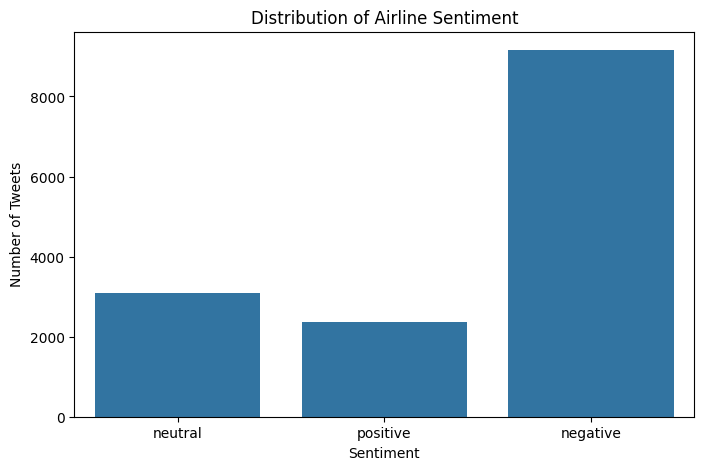

In [ ]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="airline_sentiment"
)

plt.title("Distribution of Airline Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

plt.show()

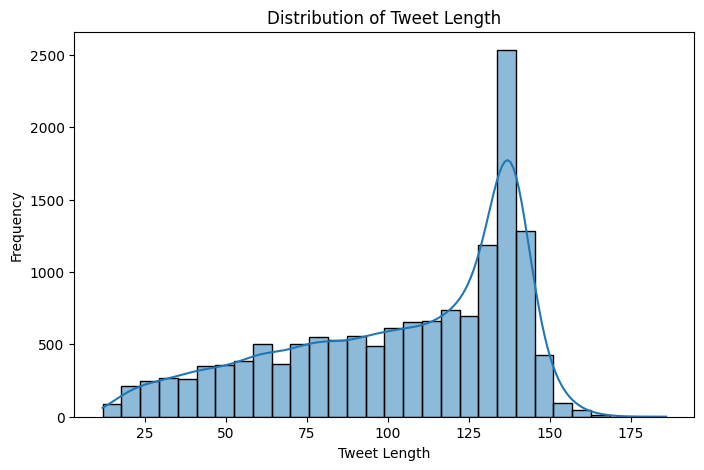

In [ ]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["tweet_length"],
    bins=30,
    kde=True
)

plt.title("Distribution of Tweet Length")
plt.xlabel("Tweet Length")
plt.ylabel("Frequency")

plt.show()

**Observation:** Negative sentiment is the dominant class in the dataset, while positive sentiment has the fewest observations, indicating noticeable class imbalance.

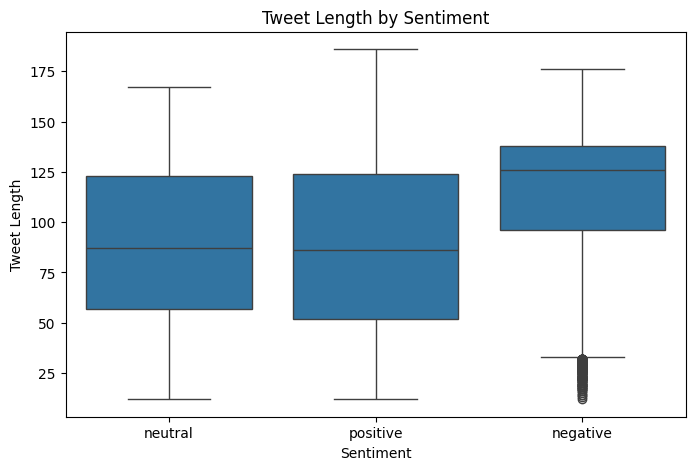

In [ ]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="airline_sentiment",
    y="tweet_length"
)

plt.title("Tweet Length by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Length")

plt.show()

In [ ]:
**Observation:** Most tweets fall within a moderate text-length range, while a smaller number of tweets are much longer than the majority.
**Observation:** Tweet length differs somewhat across sentiment groups, suggesting that customers may express complaints, neutral comments, and positive feedback using different amounts of text.

SyntaxError: invalid syntax (3335284614.py, line 1)

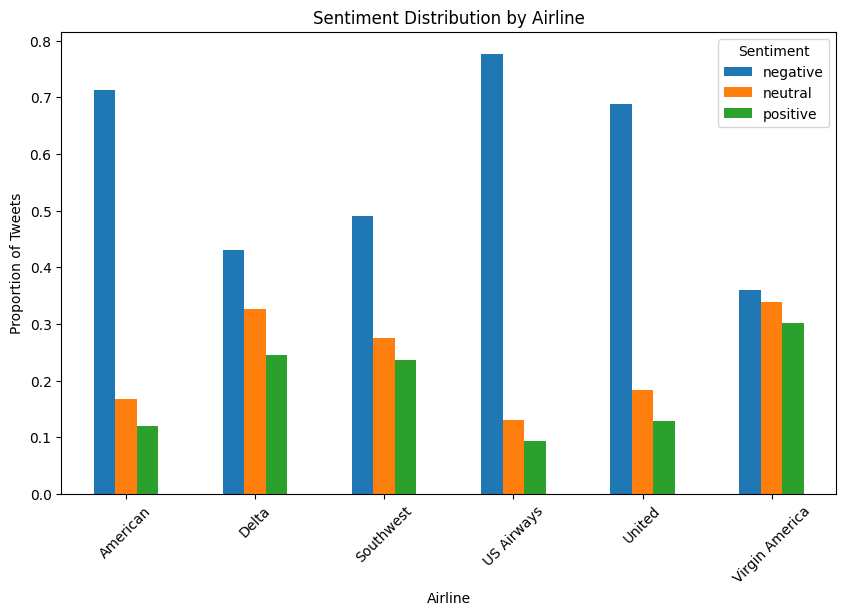

In [ ]:
airline_sentiment = pd.crosstab(
    df["airline"],
    df["airline_sentiment"],
    normalize="index"
)

airline_sentiment.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sentiment Distribution by Airline")
plt.xlabel("Airline")
plt.ylabel("Proportion of Tweets")
plt.xticks(rotation=45)

plt.legend(title="Sentiment")

plt.show()

In [ ]:
**Observation:** The proportion of negative, neutral, and positive tweets varies by airline, showing that sentiment patterns are not identical across carriers.

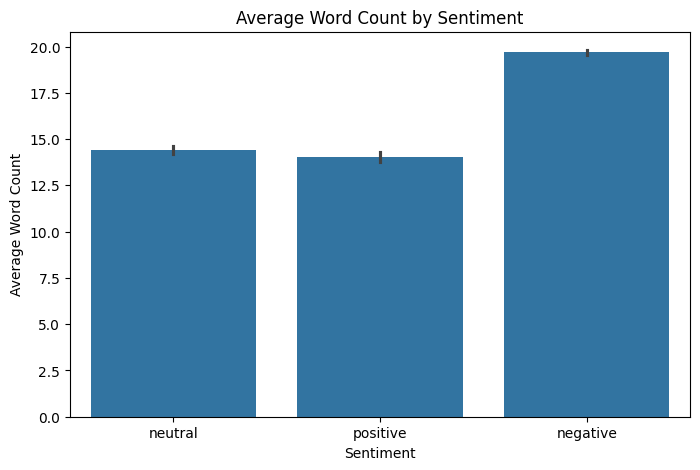

In [ ]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="airline_sentiment",
    y="word_count"
)

plt.title("Average Word Count by Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Average Word Count")

plt.show()

In [ ]:
**Observation:** Average word count varies across sentiment classes, suggesting that message length may contain useful information about how users express sentiment.

In [ ]:
sentiment_summary = df.groupby(
    "airline_sentiment"
)[
    [
        "tweet_length",
        "word_count",
        "mention_count",
        "hashtag_count"
    ]
].mean()

sentiment_summary.round(2)

,tweet_length,word_count,mention_count,hashtag_count
airline_sentiment,,,,
negative,113.92,19.68,1.12,0.25
neutral,87.40,14.42,1.17,0.22
positive,86.11,14.02,1.14,0.30


In [ ]:
## Feature Engineering Rationale

- `tweet_length` may capture sentiment intensity because customers who are frustrated or highly engaged may write longer messages.
- `word_count` provides a second measure of message size and may help distinguish brief reactions from detailed complaints or praise.
- `mention_count` may reflect interaction style, especially when customers tag airlines or other users while expressing feedback.
- `hashtag_count` may capture emphasis, topic labeling, campaigns, or emotionally expressive posting behavior.

These engineered features are used for analysis and could help a future machine-learning model, but they are not added to the required RNN input because this assignment specifies a text-sequence model.

In [ ]:
df["airline_sentiment"].value_counts()

,count
airline_sentiment,
negative,9159
neutral,3091
positive,2354


In [ ]:
pd.crosstab(
    df["airline"],
    df["airline_sentiment"]
)

airline_sentiment,negative,neutral,positive
airline,,,
American,1941,455,327
Delta,955,723,544
Southwest,1186,664,570
US Airways,2263,381,269
United,2633,697,492
Virgin America,181,171,152


In [ ]:
df["airline_sentiment"].value_counts()

,count
airline_sentiment,
negative,9159
neutral,3091
positive,2354


In [ ]:
model_df = df[
    ["text", "airline_sentiment"]
].copy()

model_df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [ ]:
# Five Key Data Insights

1. **Negative sentiment is the largest class** in the dataset, while positive sentiment is the smallest, showing that the target variable is imbalanced.
2. **Tweet length differs across sentiment groups**, indicating that the amount of text customers write may be related to how they feel about an airline.
3. **Average word count also varies by sentiment**, suggesting that some sentiment classes tend to contain more detailed messages than others.
4. **Sentiment proportions vary across airlines**, meaning customer experience is not distributed equally across carriers.
5. **Mentions and hashtags show different average usage patterns across sentiment classes**, indicating that Twitter interaction style may provide additional signals for a future model.

In [ ]:
label_encoder = LabelEncoder()

model_df["label"] = label_encoder.fit_transform(
    model_df["airline_sentiment"]
)

In [ ]:
for index, label in enumerate(label_encoder.classes_):
    print(index, "=", label)

0 = negative
1 = neutral
2 = positive


In [ ]:
X = model_df["text"].astype(str)

y = model_df["label"]

In [ ]:
n_classes = y.nunique()

print("Number of Classes:", n_classes)

Number of Classes: 3


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))

Training Samples: 11683
Testing Samples: 2921


In [ ]:
vocab_size = 5000

tokenizer = Tokenizer(
    num_words=vocab_size,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train)

In [ ]:
X_train_sequences = tokenizer.texts_to_sequences(
    X_train
)

X_test_sequences = tokenizer.texts_to_sequences(
    X_test
)

In [ ]:
max_length = 50

X_train_pad = pad_sequences(
    X_train_sequences,
    maxlen=50,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_sequences,
    maxlen=50,
    padding="post",
    truncating="post"
)

In [ ]:
print("Training Shape:", X_train_pad.shape)
print("Testing Shape:", X_test_pad.shape)

Training Shape: (11683, 50)
Testing Shape: (2921, 50)


In [ ]:
model = Sequential([
    Embedding(5000, 32),

    SimpleRNN(32),

    Dense(
        n_classes,
        activation="softmax"
    )
])

In [ ]:
model.build(input_shape=(None, 50))

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,179 (633.51 KB)

 Trainable params: 162,179 (633.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.6308 - loss: 0.8708 - val_accuracy: 0.6410 - val_loss: 0.8723
Epoch 2/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6811 - loss: 0.7799 - val_accuracy: 0.6264 - val_loss: 0.8392
Epoch 3/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7084 - loss: 0.7244 - val_accuracy: 0.6577 - val_loss: 0.8226
Epoch 4/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.7269 - loss: 0.7082 - val_accuracy: 0.6431 - val_loss: 0.8754
Epoch 5/5
293/293 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.7518 - loss: 0.6605 - val_accuracy: 0.5935 - val_loss: 0.9371


In [ ]:
test_loss, test_accuracy = model.evaluate(
    X_test_pad,
    y_test,
    verbose=0
)

print(f"Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

Test Loss: 0.9276
Final Test Accuracy: 60.32%


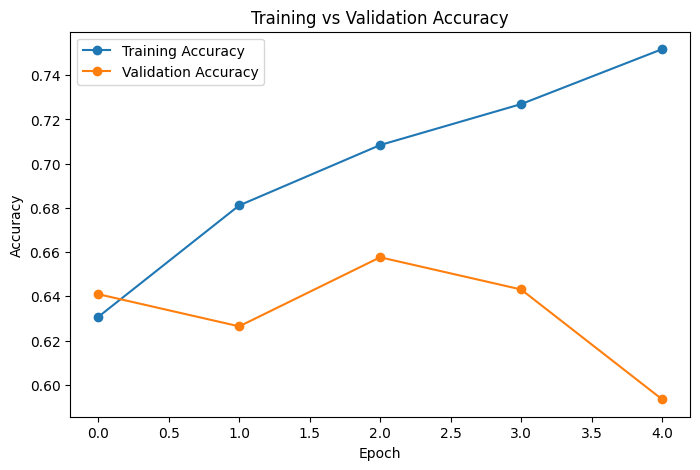

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    marker="o",
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.show()

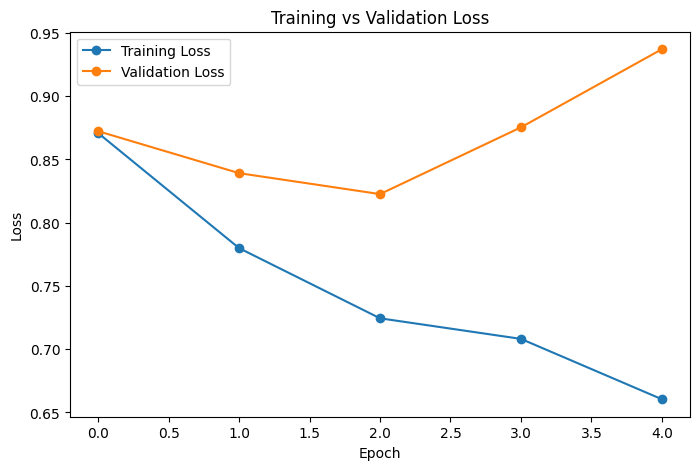

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    marker="o",
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    marker="o",
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.show()

In [ ]:
prediction_probabilities = model.predict(
    X_test_pad
)

predictions = np.argmax(
    prediction_probabilities,
    axis=1
)

92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


In [ ]:
comparison = pd.DataFrame({
    "Tweet": X_test.values[:10],
    "Actual": y_test.values[:10],
    "Predicted": predictions[:10]
})

comparison["Actual Sentiment"] = (
    label_encoder.inverse_transform(
        comparison["Actual"]
    )
)

comparison["Predicted Sentiment"] = (
    label_encoder.inverse_transform(
        comparison["Predicted"]
    )
)

comparison[
    [
        "Tweet",
        "Actual Sentiment",
        "Predicted Sentiment"
    ]
]

,Tweet,Actual Sentiment,Predicted Sentiment
0,@USAirways call Gate D9 in CLT and get me on t...,neutral,positive
1,"@united I appreciate the immediate offer, but ...",negative,negative
2,@united Will you be issuing an exception polic...,neutral,negative
3,@SouthwestAir Thanks for helping my mom after ...,positive,negative
4,@united have reported it. Still in Istanbul a...,positive,negative
5,"@AmericanAir flight 1388 tomorrow 5:15 am, sta...",neutral,negative
6,@VirginAmerica That's classy.,positive,negative
7,@USAirways flying high thanks!,positive,positive
8,@united \nFlight UA1665 got delayed 2 hours du...,negative,negative
9,@SouthwestAir me again! I was just trying to r...,negative,negative
